# **Compare and Analyze Training Results**

In [1]:
import sys
import os

project_path = "/home/sagemaker-user/gbm_hackathon"
if project_path not in sys.path:
    sys.path.append(project_path)
    print(sys.path)

['/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python310.zip', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/lib-dynload', '', '/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages', '/home/sagemaker-user/gbm_hackathon']


In [2]:
%load_ext autoreload
%autoreload 2
from gbmhackathon.training.cv import plot_cv_table, plot_results_cv

## **All results**

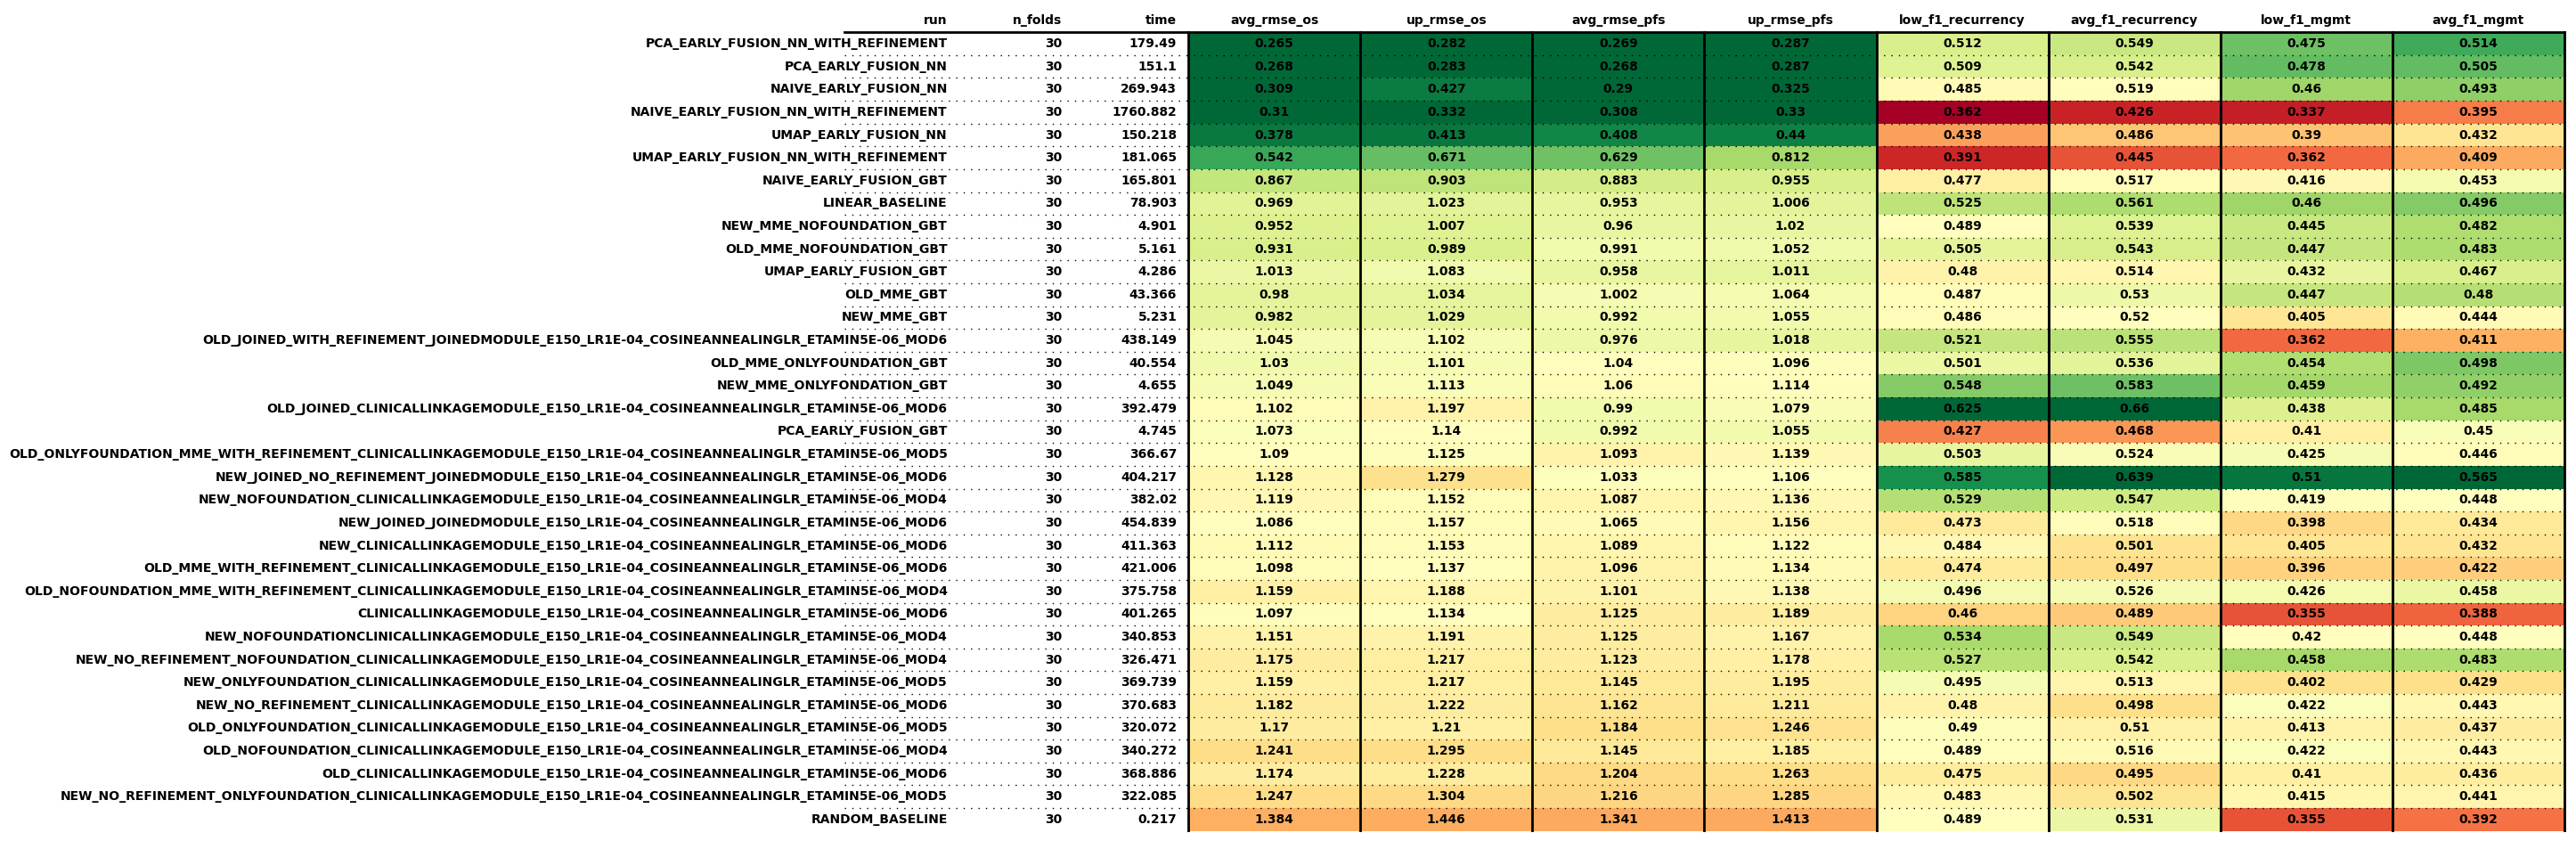

In [3]:
plot_cv_table('../results/cv_results.csv', figsize=(25,12))

### That's a lot, let's dive into it
## **Early Fusion**

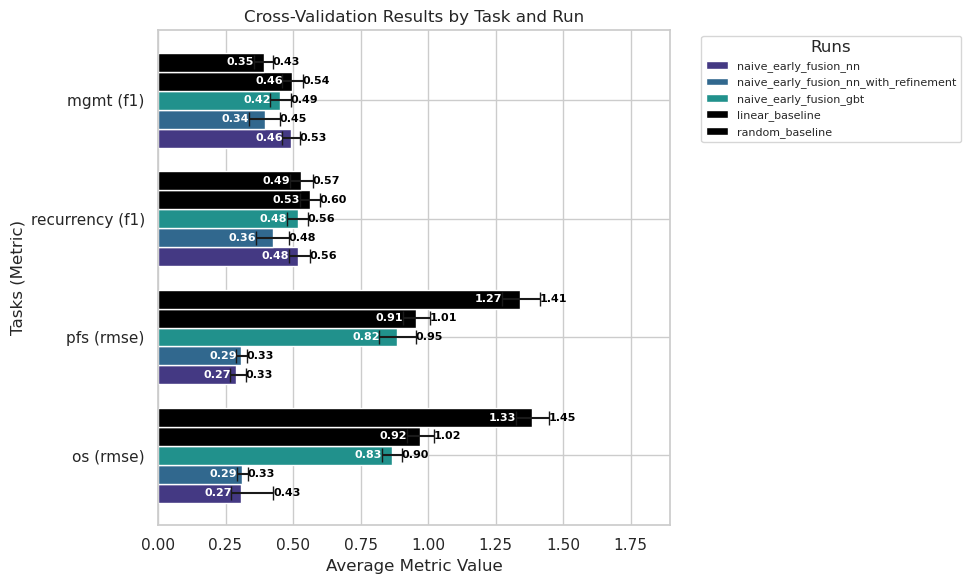

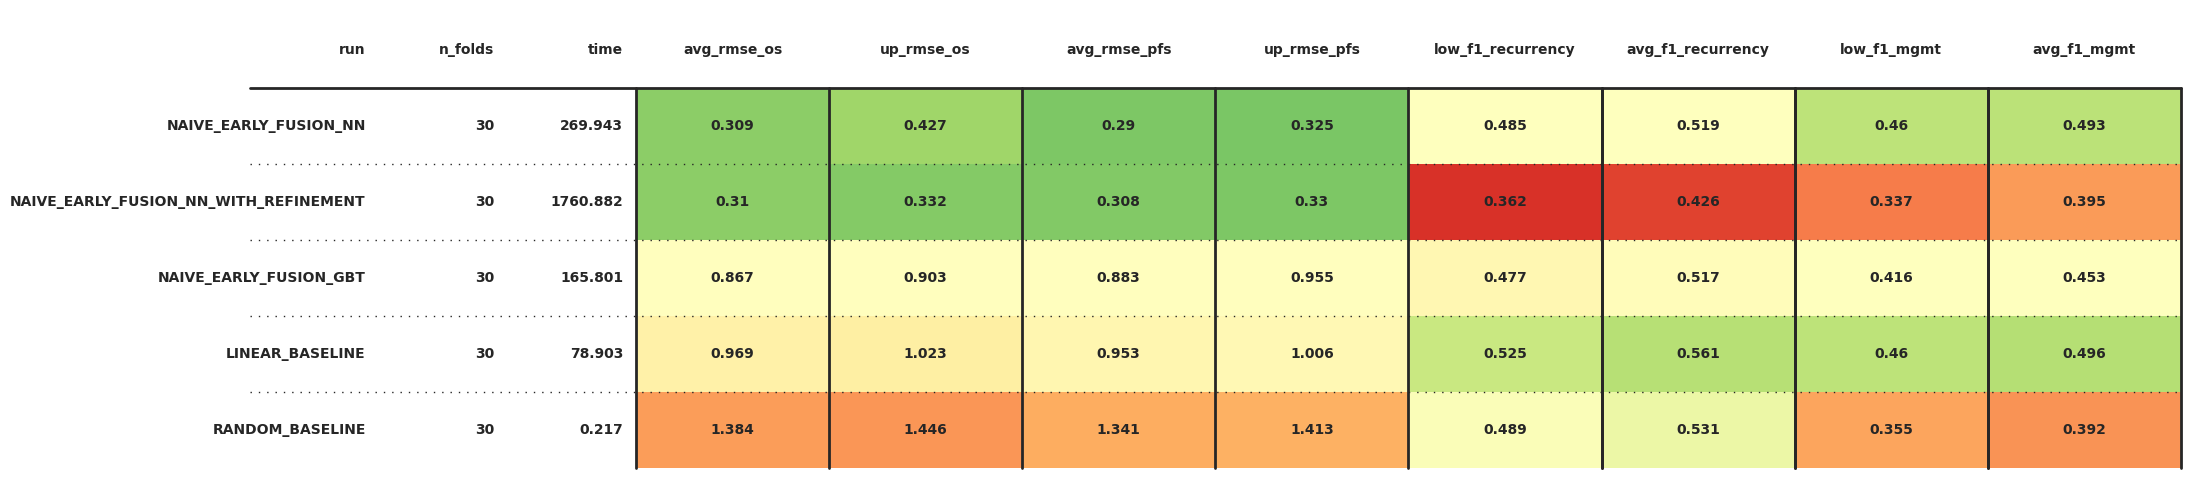

In [4]:
plot_results_cv('../results/cv_results.csv', run_filter='naive_early', figsize=(10,6))

Regression results are good when using the Neural network. They are similar with or without the refinement block. Overall, appraoches are useful if we compare them to a random baseline on regression tasks.
Classification results are not good regardless of using ML or DL since, overall, they have similar confidence intervals as the random baseline. Globally, the Gradient Boosting Tree does not perform very well in this setting which is expected due to the extremely large dimensionality of the feature space (9554). It seems to suffer from the curse of dimensionality.  
Best performances are obtained with **Naive Fusion with an ensemble of MLPs (1 per task)**:  
**Overall Survival (os) = 0.309**  
**Progression Free Years (pfs) = 0.29**   
**Recurrency = 0.519**   
**MGMT Promoter Methylation = 0.493**   
Can we improve performance by reducing the dimension ?

/home/sagemaker-user/gbm_hackathon/gbmhackathon/training/cv.py:263: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df = df[df['run'].str.contains(run_filter)]


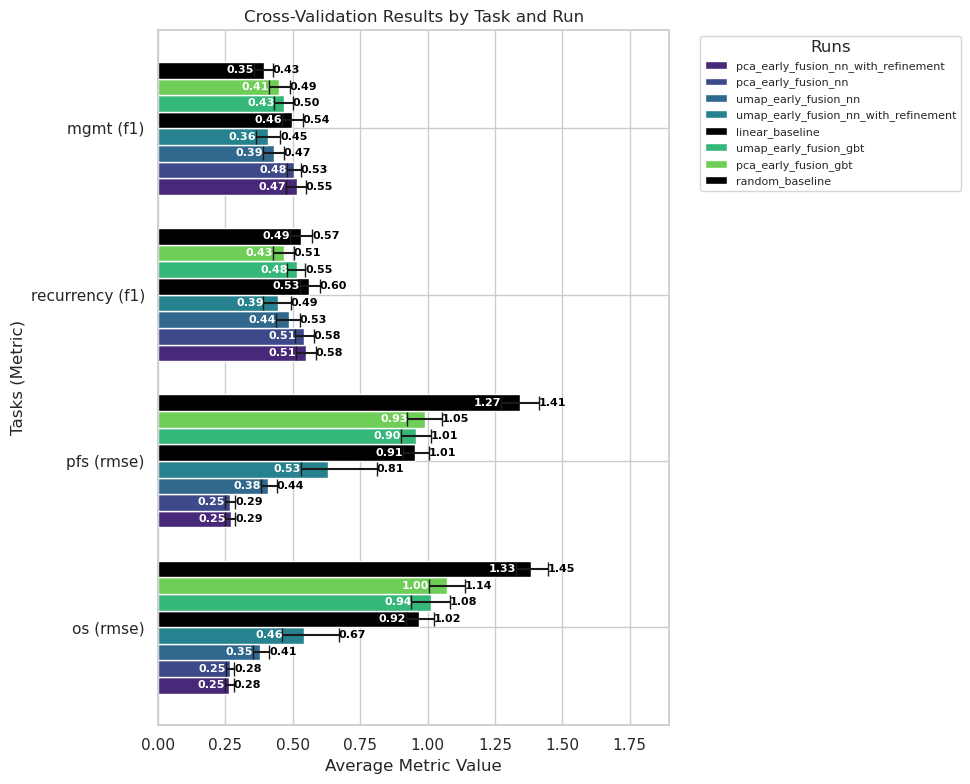

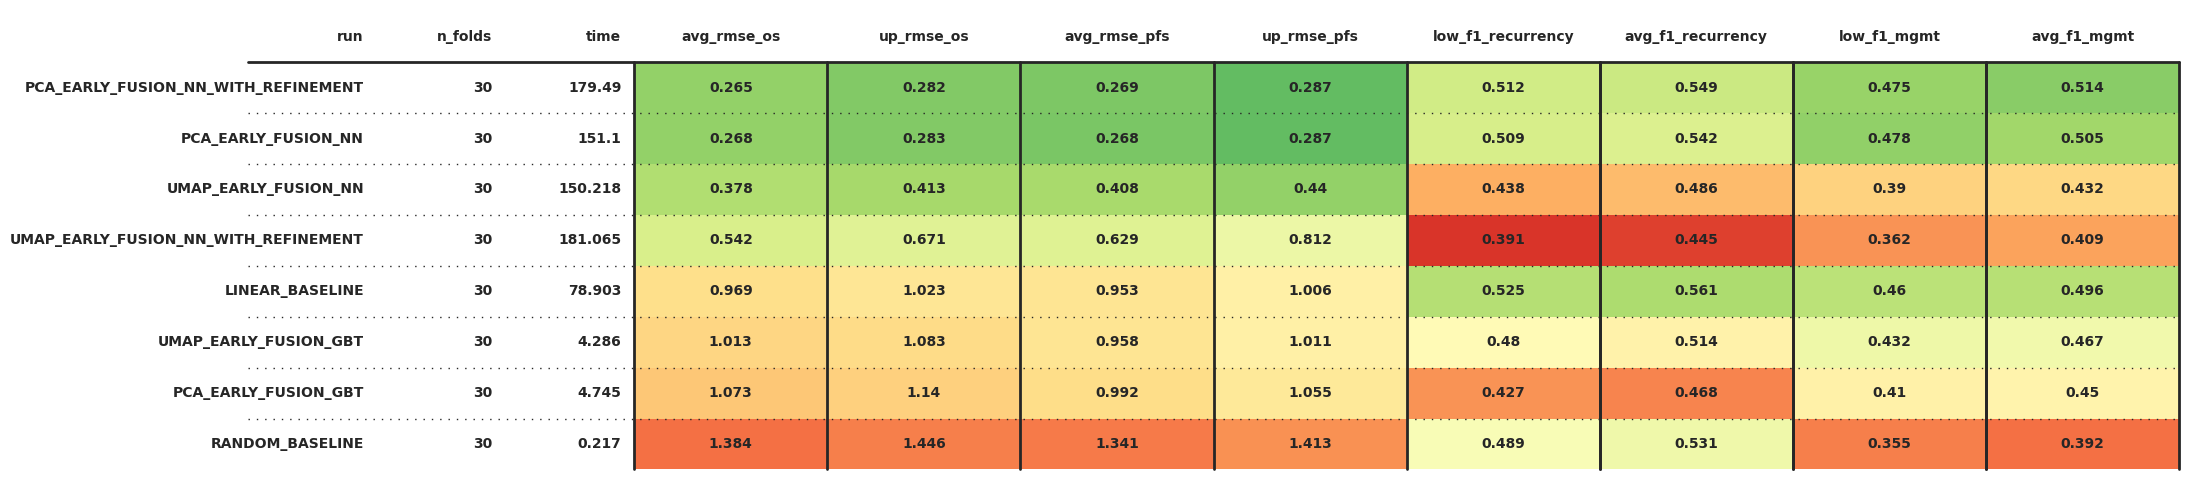

In [5]:
plot_results_cv('../results/cv_results.csv', run_filter='(pca|umap)_early_fusion|linear_baseline')

Using Dimensionality reduction slightly improve results when using the neural network. Surprinsingly, the gradient boosting tree does not improve and even gets slightly worse results which was not expected. UMAP reduction step yields worse downstream performances than PCA.  
Best performances are obtained with **Early Fusion with PCA with our clinical linkage module (RefinementBlock + 1 MLP per task)**:  
**Overall Survival (os) = 0.265 (14% performance increase)**   
**Progression Free Years (pfs) = 0.269 (7% performance increase)**  
**Recurrency = 0.549 (5% performance increase)**  
**MGMT Promoter Methylation = 0.514 (4% performance increase)**  

### **Conclusion on Early Fusion**
The above results suggest that using a Neural network is indeed a viable approach even for this very low-N setting. Using PCA improves results. The refinement block does not yield significantly different results compared to the ensemble of MLPs alone. A surprising result stems from the inability of the gradient boosting tree to effectively predict regression targets from the input feature space. **This highlights that in such settings where the input feature space is of incredible complexity, neural networks are a viable solution to effectively explore and extract signal from data.** On regression task, both ML and DL appraoches are limited and close to the random baseline (except NN with PCA)

## **THREADS-like contrastive phase (old framework)**

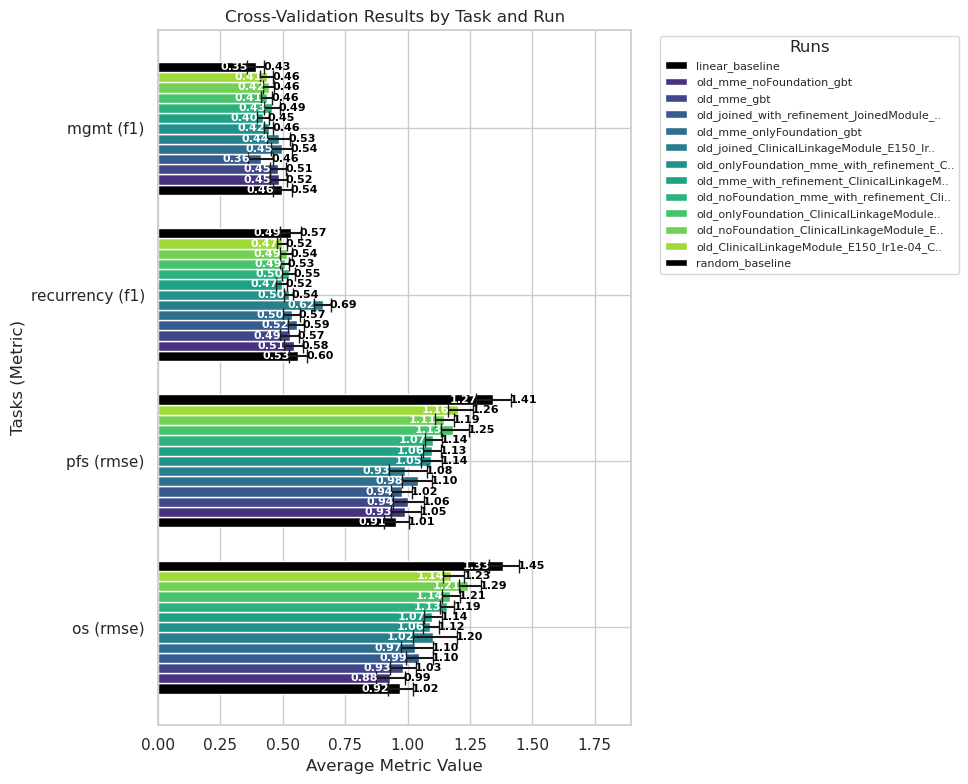

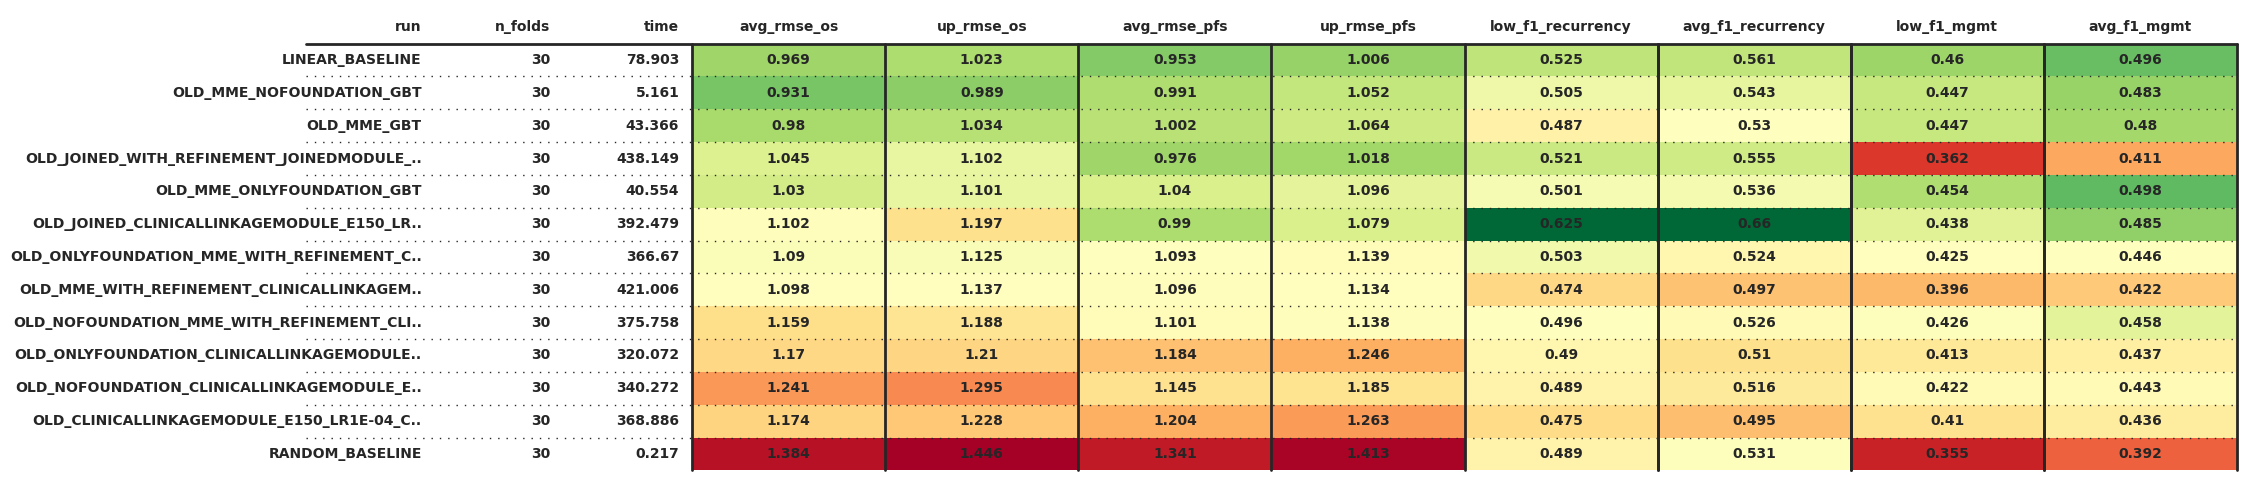

In [6]:
plot_results_cv('../results/cv_results.csv', run_filter='old|linear_baseline', clip_runs=True)

Results show that using the joined optimization after the old framewokr yields **significantly better** results for recurrency prediction reaching at best **0.66 F1 score on Recurrency (joined with refinement block)**. Using a Gradient Boosting Tree on the MME embeddings obtained through this framework also yield significantly better results than the random classifier with an average F1 score of 0.498. However only the former beats both random and linear baselines on recurrency. On all other tasks, none of our approaches are significantly better than the linear baseline.

No significant differences are observable between Only Foundation, No FOundation, Normal dataset: **The issue does not seems to mostly not come from the input feature space.** Rather the **contrastive phase itself on such a limited dataset seems to be the issue**, it seem we are degrading the information somehow since a simple concatenation yields much better results. 

## **Modality wise contrastive phase (new framework)**

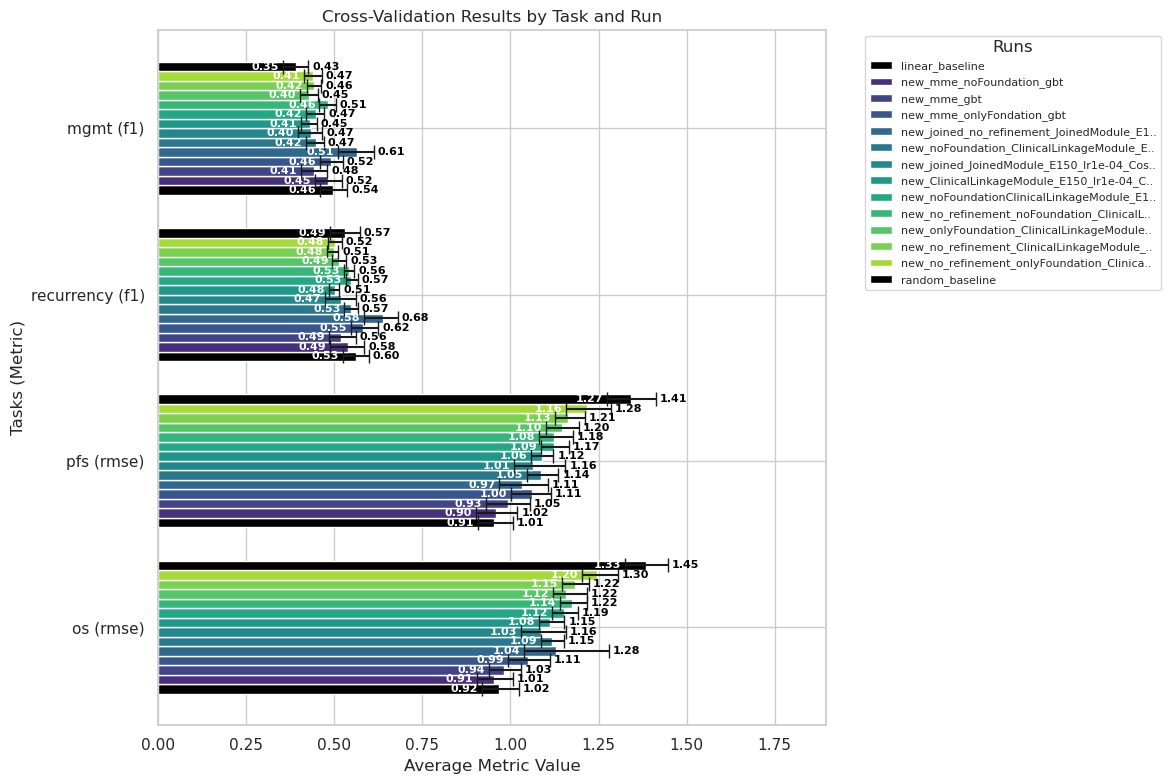

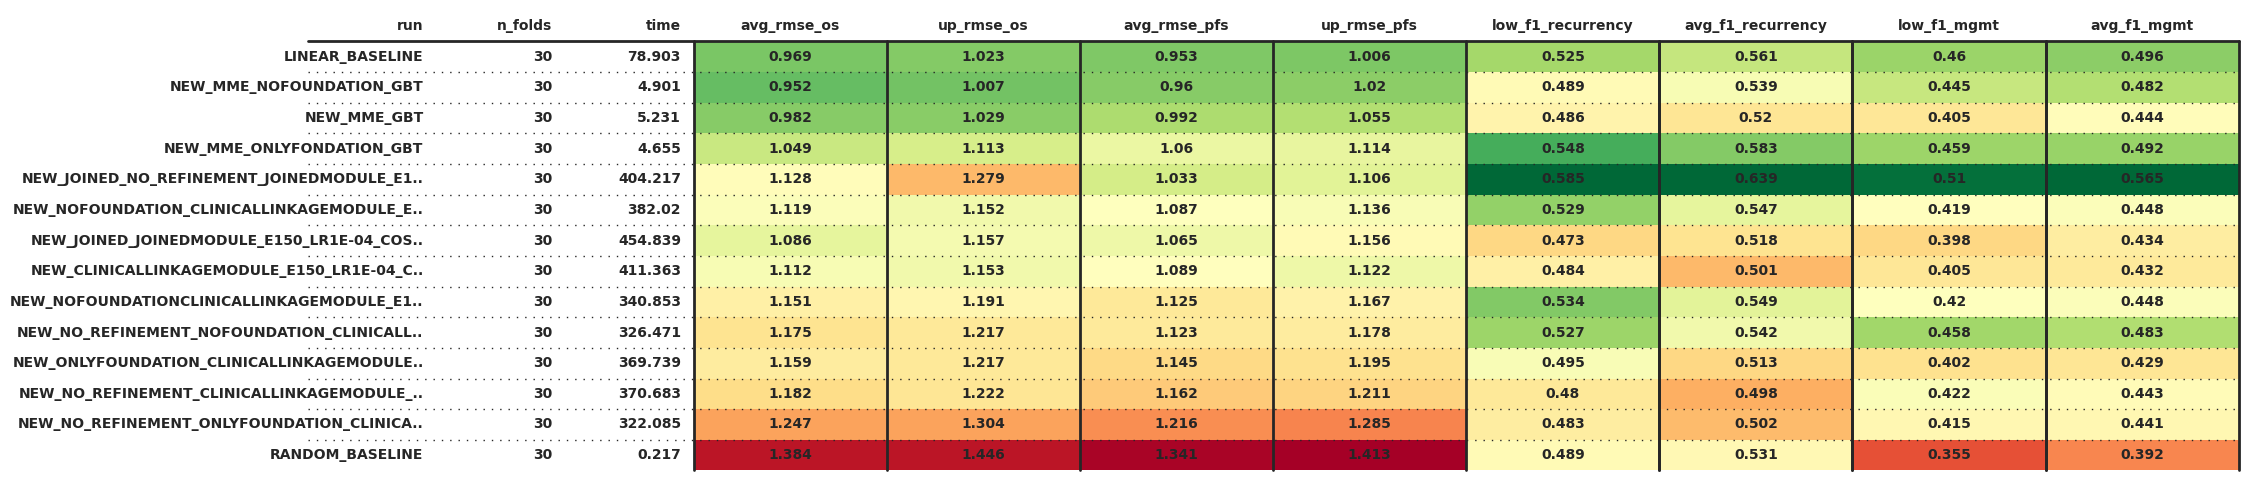

In [7]:
plot_results_cv('../results/cv_results.csv', run_filter='new|linear_baseline', clip_runs=True, figsize=(12,8))

Although not truly significant, **a visible and important boost of performances** can be observed when using **joined optimization after the new framework without the refinement block** on both **classification tasks**, reaching **0.639 and 0.565 F1 score** respectively for Recurrency and MGMT promoter methylation. This shows that **the constrastive phase did help** by providing a **useful warmstart of the MME weights** before clinical linkage.

**Let's look at both frameworks best results and compare them with early fusion best.**

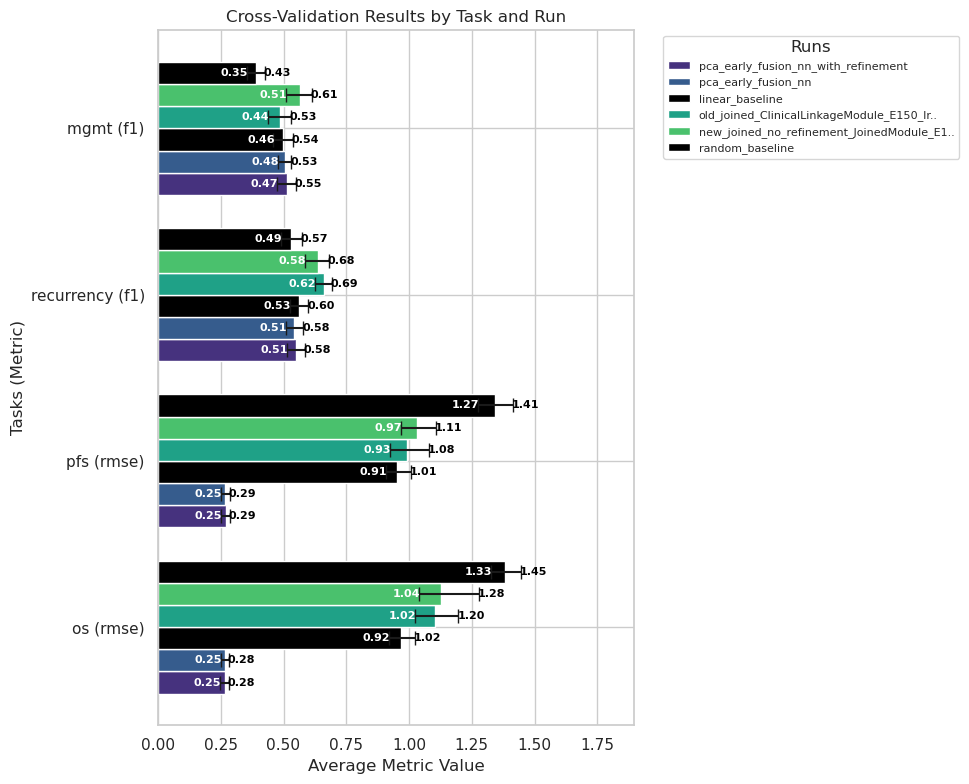

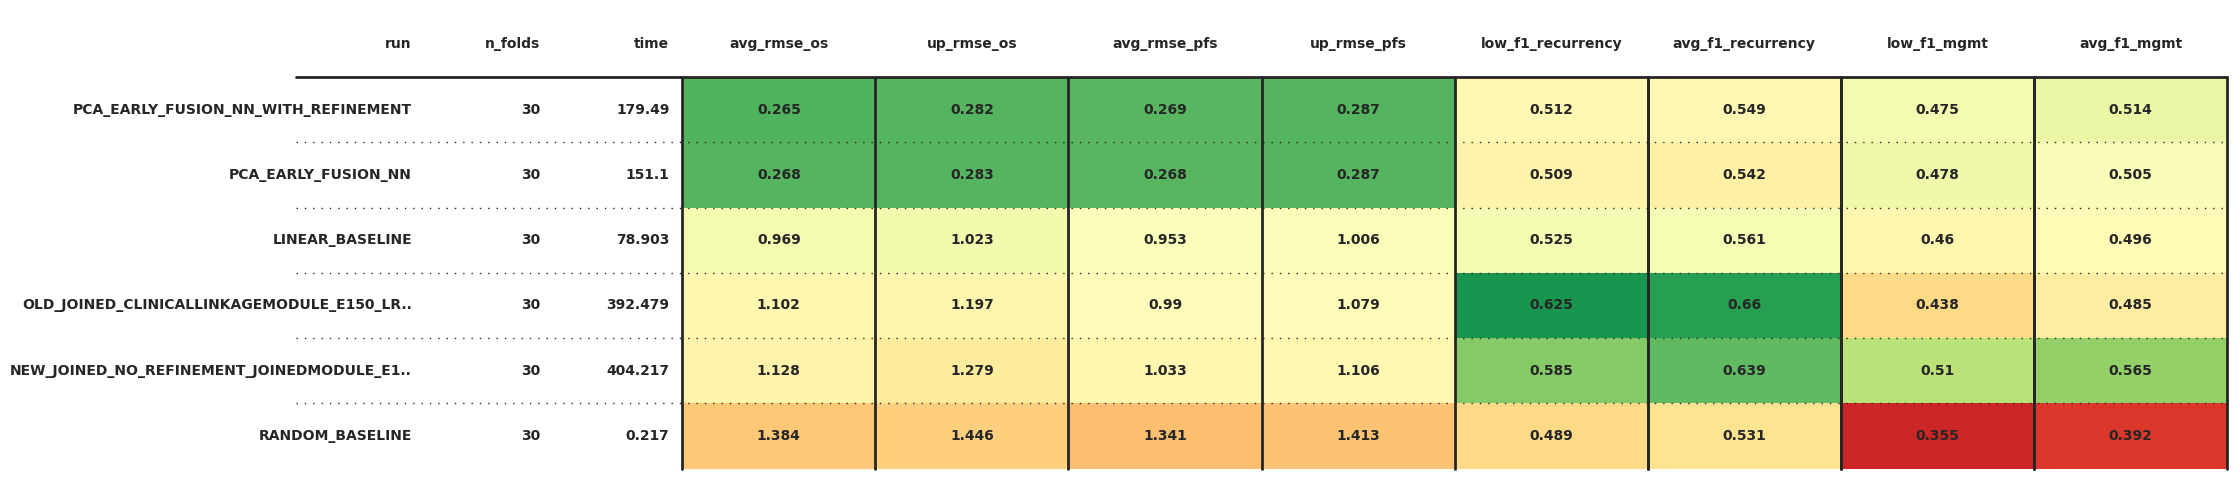

In [14]:
plot_results_cv('../results/cv_results.csv', run_filter='new_joined_no|old_joined_C|pca_early_fusion_nn', clip_runs=True)

**There is no significant difference between both frameworks**. The contrastive approaches lead to **similar results for classification tasks** which are slightly, but importantly, better than naive appraoches on these tasks. On regression tasks however, using any contrastive phase prior to the clinical linkage leads to a complete loss of signal. 

## **Focus on CLinicalLinkageModule**

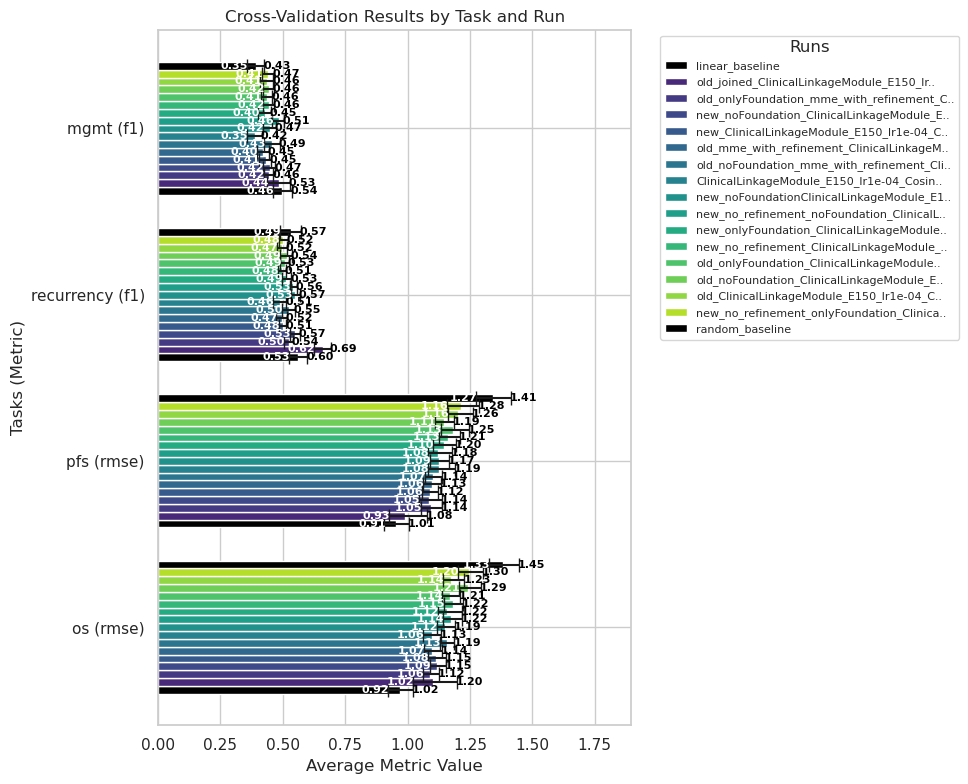

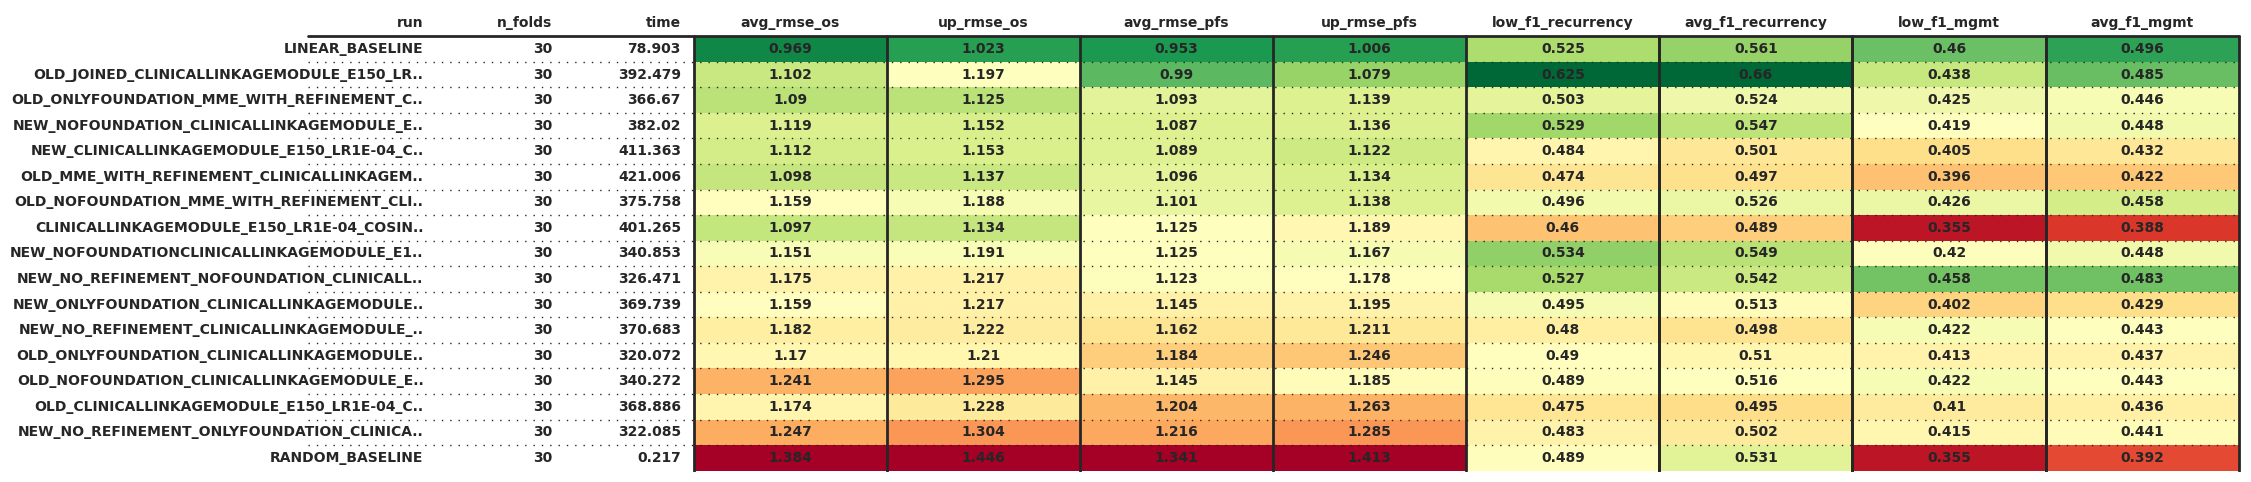

In [9]:
plot_results_cv('../results/cv_results.csv', run_filter='ClinicalLinkage', clip_runs=True)

Same conclusion as before on classification tasks but the modality wise framework withut refinement and using no foundation models embeddings yields slightly better performances on both classification tasks.

## **Focus on continuous learning of the MME**

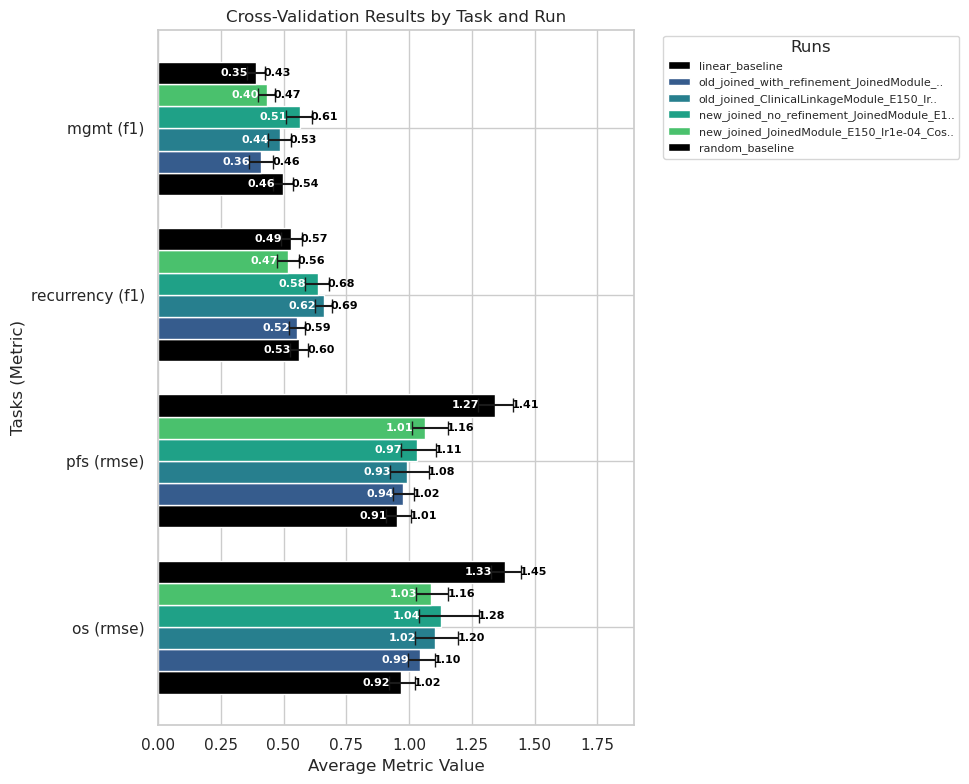

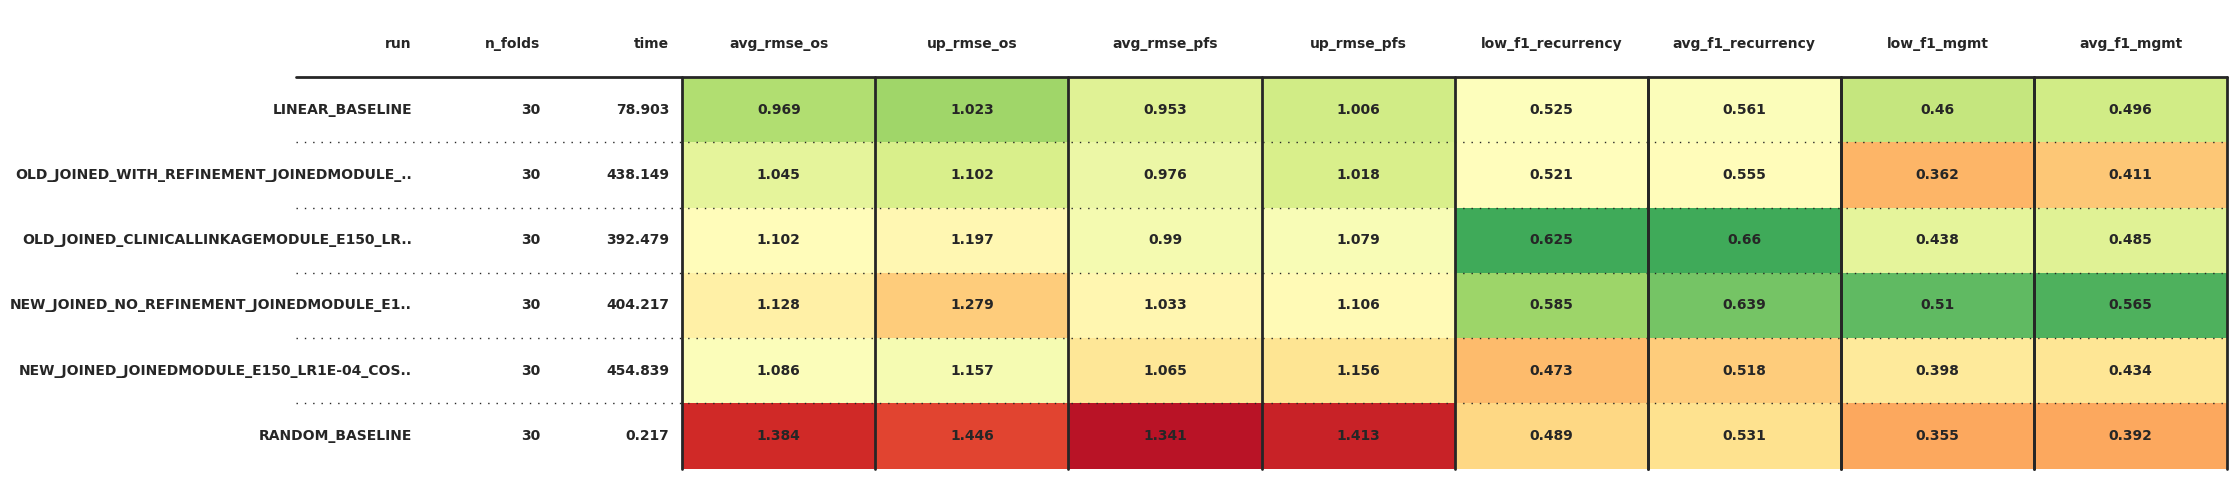

In [15]:
plot_results_cv('../results/cv_results.csv', run_filter='joined', clip_runs=True)

Best classification performances are obtained using joined phase 2.